# Rossmann Store Sales

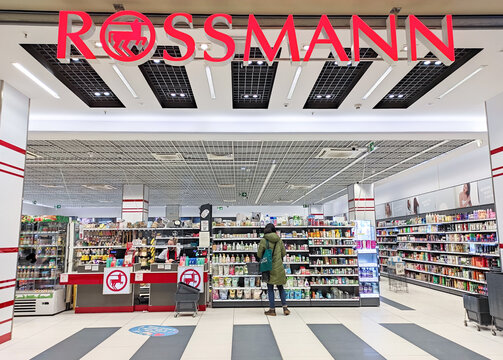

## Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score, root_mean_squared_error

In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor

In [4]:
path = "C:/Users/bianc/OneDrive/Documents/1-Estudos/2-DNC/1-Data Science/1-Material/Materis9-Modelos_de_Classificacao_Regressao/Regressao/Regressao-main/Datasets/rossman_store_sales.csv/"

In [6]:
path

'C:/Users/bianc/OneDrive/Documents/1-Estudos/2-DNC/1-Data Science/1-Material/Materis9-Modelos_de_Classificacao_Regressao/Regressao/Regressao-main/Datasets/rossman_store_sales.csv/'

In [5]:
df_sales = pd.read_csv(path + "rossman_store_sales.csv")

C:\Users\bianc\AppData\Local\Temp\ipykernel_36788\4047263359.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df_sales = pd.read_csv(path + "rossman_store_sales.csv")


In [7]:
df_sales.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [8]:
df_sales.shape

(1017209, 9)

## Preparando Dados

In [9]:
df_sales["Date"] = pd.to_datetime(df_sales["Date"])

In [10]:
df_sales["Store"].nunique()

1115

In [11]:
# Agrupando dados por data para construir série temporal.
# Case: previsão de vendas diária considerando todas as lojas
df = df_sales.groupby("Date")["Sales"].sum()

<Axes: xlabel='Date'>

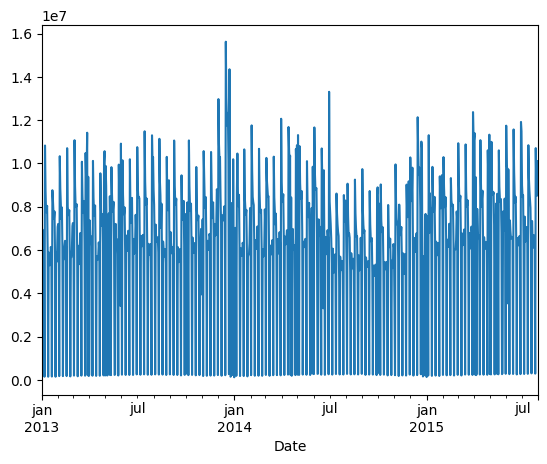

In [12]:
df.plot()

## Separação de dados para Séries Temporais

In [13]:
train = df.loc[:"2014-12-31"]
test = df.loc["2015-01-01":]

In [14]:
print(f"Train: {train.index.min()} - {train.index.max()}")

Train: 2013-01-01 00:00:00 - 2014-12-31 00:00:00


In [15]:
print(f"Test: {test.index.min()} - {test.index.max()}")

Test: 2015-01-01 00:00:00 - 2015-07-31 00:00:00


In [16]:
from sklearn.model_selection import TimeSeriesSplit

Janela Expansiva

In [17]:
tscv = TimeSeriesSplit(n_splits=3)

for train_index, test_index in tscv.split(df):
  train_fold = df.iloc[train_index]
  test_fold = df.iloc[test_index]

  print("Train Size", train_fold.shape)
  print(f"Train: {train_fold.index.min()} - {train_fold.index.max()}")
  print(f"Test: {test_fold.index.min()} - {test_fold.index.max()}")
  print("##### \n")

Train Size (237,)
Train: 2013-01-01 00:00:00 - 2013-08-25 00:00:00
Test: 2013-08-26 00:00:00 - 2014-04-17 00:00:00
##### 

Train Size (472,)
Train: 2013-01-01 00:00:00 - 2014-04-17 00:00:00
Test: 2014-04-18 00:00:00 - 2014-12-08 00:00:00
##### 

Train Size (707,)
Train: 2013-01-01 00:00:00 - 2014-12-08 00:00:00
Test: 2014-12-09 00:00:00 - 2015-07-31 00:00:00
##### 



Janela Deslizante

In [ ]:
tscv = TimeSeriesSplit(n_splits=3, max_train_size=237) # o que muda é a definição do max_train_size  

for train_index, test_index in tscv.split(df):
  train_fold = df.iloc[train_index]
  test_fold = df.iloc[test_index]

  print(f"Train: {train_fold.index.min()} - {train_fold.index.max()}")
  print(f"Test: {test_fold.index.min()} - {test_fold.index.max()}")
  print("##### \n")

Train: 2013-01-01 00:00:00 - 2013-08-25 00:00:00
Test: 2013-08-26 00:00:00 - 2014-04-17 00:00:00
##### 

Train: 2013-08-24 00:00:00 - 2014-04-17 00:00:00
Test: 2014-04-18 00:00:00 - 2014-12-08 00:00:00
##### 

Train: 2014-04-16 00:00:00 - 2014-12-08 00:00:00
Test: 2014-12-09 00:00:00 - 2015-07-31 00:00:00
##### 



## Analisando a série e criando features para o modelo de Machine Learning

<Axes: xlabel='Date'>

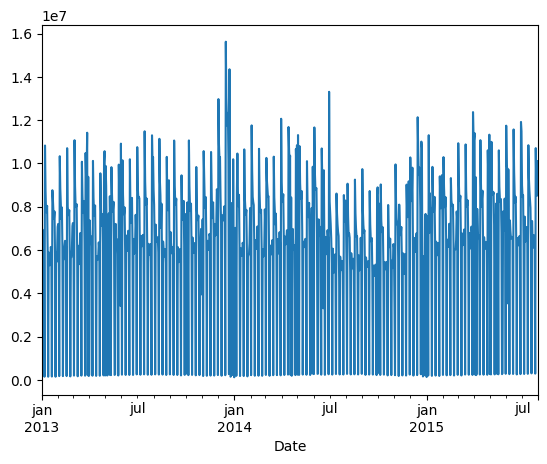

In [19]:
df.plot()

<Axes: xlabel='Date'>

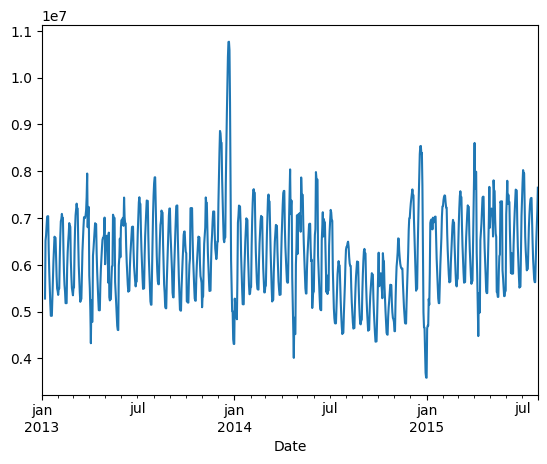

In [ ]:
df.rolling(7).mean().plot() 
# Plotando a média móvel de 7 dias

In [23]:
df = df.to_frame()
df.head()

,Sales
Date,
2013-01-01,97235
2013-01-02,6949829
2013-01-03,6347820
2013-01-04,6638954
2013-01-05,5951593


In [25]:
# Criando lags de 1 a 7 dias
for lag in [1,2,3,4,5,6,7]:
  df[f"lag_{lag}"] = df["Sales"].shift(lag)

In [32]:
df.shift(2)

,Sales,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,moving_avg_7,moving_avg_15,moving_avg_30
Date,,,,,,,,,,,
2013-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-01-03,97235.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-01-04,6949829.0,97235.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-01-05,6347820.0,6949829.0,97235.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
2015-07-27,6021666.0,6601325.0,6687068.0,6110388.0,6356482.0,7339321.0,298418.0,6448982.0,5.691712e+06,6.580465e+06,6.727740e+06
2015-07-28,285865.0,6021666.0,6601325.0,6687068.0,6110388.0,6356482.0,7339321.0,298418.0,5.630667e+06,6.510916e+06,6.721403e+06
2015-07-29,10707292.0,285865.0,6021666.0,6601325.0,6687068.0,6110388.0,6356482.0,7339321.0,5.628874e+06,6.112505e+06,6.509776e+06


In [26]:
df.head()

,Sales,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7
Date,,,,,,,,
2013-01-01,97235,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-01-02,6949829,97235.0,NaN,NaN,NaN,NaN,NaN,NaN
2013-01-03,6347820,6949829.0,97235.0,NaN,NaN,NaN,NaN,NaN
2013-01-04,6638954,6347820.0,6949829.0,97235.0,NaN,NaN,NaN,NaN
2013-01-05,5951593,6638954.0,6347820.0,6949829.0,97235.0,NaN,NaN,NaN


In [28]:
for window in [7, 15, 30]:
  df[f"moving_avg_{window}"] = df["Sales"].shift(1).rolling(window).mean()

## Separando dados para utilizar no modelo

In [33]:
from sklearn.model_selection import train_test_split

In [34]:
train, test = train_test_split(df, test_size=0.3, shuffle=False)

In [35]:
train

,Sales,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,moving_avg_7,moving_avg_15,moving_avg_30
Date,,,,,,,,,,,
2013-01-01,97235,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-01-02,6949829,97235.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-01-03,6347820,6949829.0,97235.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-01-04,6638954,6347820.0,6949829.0,97235.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-01-05,5951593,6638954.0,6347820.0,6949829.0,97235.0,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
2014-10-17,5449686,5179446.0,5110401.0,5213744.0,5445980.0,240423.0,5190193.0,7047404.0,4.775370e+06,5.239416e+06,5.296749e+06
2014-10-18,4945733,5449686.0,5179446.0,5110401.0,5213744.0,5445980.0,240423.0,5190193.0,4.547125e+06,5.059009e+06,5.261281e+06
2014-10-19,204991,4945733.0,5449686.0,5179446.0,5110401.0,5213744.0,5445980.0,240423.0,4.512202e+06,5.368192e+06,5.212889e+06


In [36]:
test

,Sales,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,moving_avg_7,moving_avg_15,moving_avg_30
Date,,,,,,,,,,,
2014-10-22,6129832,6677374.0,8078830.0,204991.0,4945733.0,5449686.0,5179446.0,5110401.0,5.092352e+06,5.320238e+06,5.321312e+06
2014-10-23,6463607,6129832.0,6677374.0,8078830.0,204991.0,4945733.0,5449686.0,5179446.0,5.237985e+06,5.240041e+06,5.349719e+06
2014-10-24,6523289,6463607.0,6129832.0,6677374.0,8078830.0,204991.0,4945733.0,5449686.0,5.421436e+06,5.212963e+06,5.399268e+06
2014-10-25,4894704,6523289.0,6463607.0,6129832.0,6677374.0,8078830.0,204991.0,4945733.0,5.574808e+06,5.193396e+06,5.456511e+06
2014-10-26,219359,4894704.0,6523289.0,6463607.0,6129832.0,6677374.0,8078830.0,204991.0,5.567518e+06,5.049882e+06,5.454015e+06
...,...,...,...,...,...,...,...,...,...,...,...
2015-07-27,10707292,285865.0,6021666.0,6601325.0,6687068.0,6110388.0,6356482.0,7339321.0,5.628874e+06,6.112505e+06,6.509776e+06
2015-07-28,9115073,10707292.0,285865.0,6021666.0,6601325.0,6687068.0,6110388.0,6356482.0,6.110012e+06,6.807855e+06,6.648742e+06
2015-07-29,8499962,9115073.0,10707292.0,285865.0,6021666.0,6601325.0,6687068.0,6110388.0,6.504097e+06,6.692775e+06,6.943822e+06


In [37]:
train = train.dropna()

In [38]:
train.shape

(629, 11)

In [39]:
X_train = train.drop("Sales", axis=1)
X_test = test.drop("Sales", axis=1)

y_train = train["Sales"]
y_test = test["Sales"]

In [40]:
y_test.mean()

np.float64(6422312.349823321)

## Treinando modelo de ML para prever vendas no dia seguinte

In [41]:
from sklearn.ensemble import RandomForestRegressor

In [42]:
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [43]:
y_pred = model.predict(X_test)

In [44]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

In [45]:
mae = mean_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)

print("MAE", mae)
print("MAPE", mape)

MAE 926173.7687279152
MAPE 1.1567805297064324


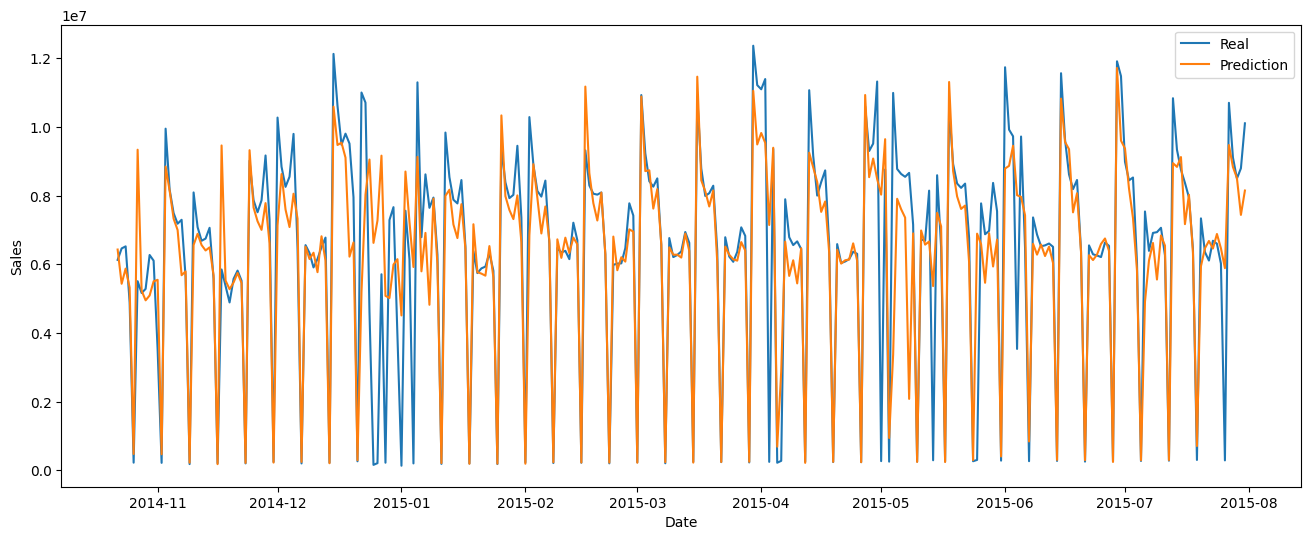

In [46]:
plt.figure(figsize=(16,6))
plt.plot(y_test.index, y_test, label="Real")
plt.plot(y_test.index, y_pred, label="Prediction")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

## Criando novas features para melhorar as previsões

In [47]:
df_sales

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1
...,...,...,...,...,...,...,...,...,...
1017204,1111,2,2013-01-01,0,0,0,0,a,1
1017205,1112,2,2013-01-01,0,0,0,0,a,1
1017206,1113,2,2013-01-01,0,0,0,0,a,1
1017207,1114,2,2013-01-01,0,0,0,0,a,1


In [48]:
df_open_features = df_sales.groupby("Date")["Open"].sum()

In [49]:
df_promo_features = df_sales.groupby("Date")["Promo"].sum()

In [50]:
df = pd.concat([df, df_open_features, df_promo_features], axis=1)

In [51]:
df["DayOfWeek"] = df.index.dayofweek

In [52]:
df

,Sales,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,moving_avg_7,moving_avg_15,moving_avg_30,Open,Promo,DayOfWeek
Date,,,,,,,,,,,,,,
2013-01-01,97235,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17,0,1
2013-01-02,6949829,97235.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1111,0,2
2013-01-03,6347820,6949829.0,97235.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1109,0,3
2013-01-04,6638954,6347820.0,6949829.0,97235.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1108,0,4
2013-01-05,5951593,6638954.0,6347820.0,6949829.0,97235.0,NaN,NaN,NaN,NaN,NaN,NaN,1107,0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2015-07-27,10707292,285865.0,6021666.0,6601325.0,6687068.0,6110388.0,6356482.0,7339321.0,5.628874e+06,6.112505e+06,6.509776e+06,1113,1115,0
2015-07-28,9115073,10707292.0,285865.0,6021666.0,6601325.0,6687068.0,6110388.0,6356482.0,6.110012e+06,6.807855e+06,6.648742e+06,1113,1115,1
2015-07-29,8499962,9115073.0,10707292.0,285865.0,6021666.0,6601325.0,6687068.0,6110388.0,6.504097e+06,6.692775e+06,6.943822e+06,1113,1115,2


In [53]:
train, test = train_test_split(df, test_size=0.3, shuffle=False)

X_train = train.drop("Sales", axis=1)
X_test = test.drop("Sales", axis=1)

y_train = train["Sales"]
y_test = test["Sales"]

In [54]:
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [55]:
print("MAE", mean_absolute_error(y_test, y_pred))
print("MAPE", mean_absolute_percentage_error(y_test, y_pred))

MAE 480839.6195759716
MAPE 0.07465273259238767


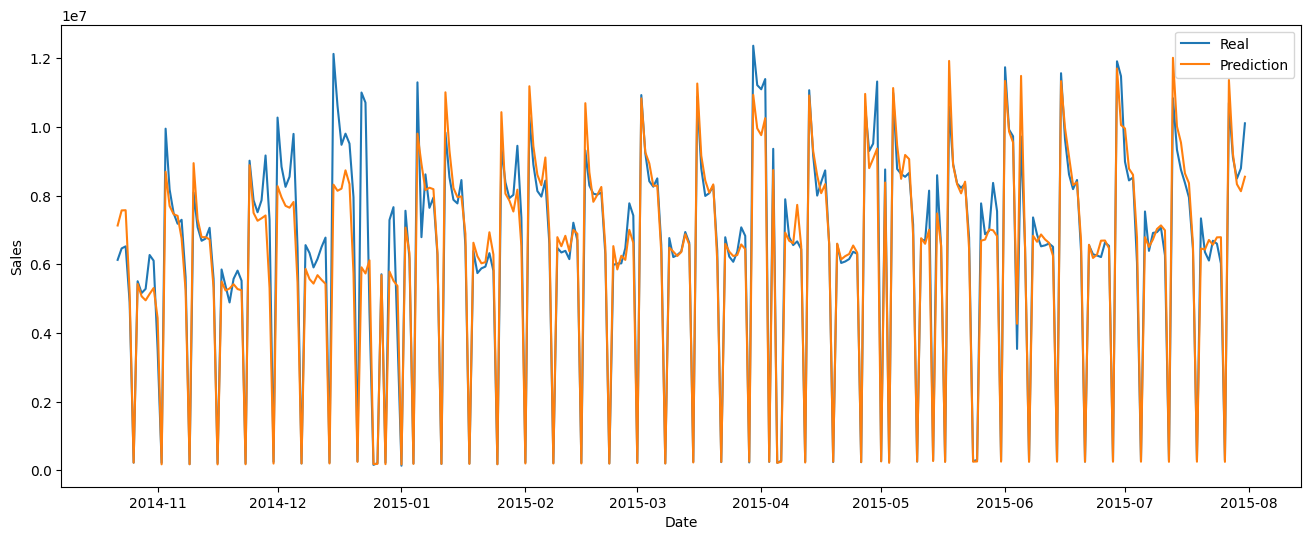

In [56]:
plt.figure(figsize=(16,6))
plt.plot(y_test.index, y_test, label="Real")
plt.plot(y_test.index, y_pred, label="Prediction")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()